# Self-Pruning Neural Network for CIFAR-10 Classification

A feed-forward network that learns to prune itself via **learnable sigmoid gates + L1 regularisation**.

| Detail | Value |
|--------|-------|
| **Author** | Inesh |
| **Date** | 2026-04-24 |
| **Runtime** | GPU T4 |
| **Epochs** | 25 |
| **λ values** | 1e-4, 5e-4, 2e-3 |


## Cell 1 — Colab Setup & GPU Check

In [1]:
# Check GPU availability
import torch, torchvision, sys

print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")


Python       : 3.12.13
PyTorch      : 2.10.0+cu128
torchvision  : 0.25.0+cu128
CUDA available: True
GPU          : Tesla T4


## 🛠️ Cell 2 — Imports & Device

In [2]:
import os, time, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = "/content/results"
DATA_DIR   = "/content/data"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR,   exist_ok=True)

def get_device():
    if torch.cuda.is_available():    return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print(f"Active device: {DEVICE}")


Active device: cuda


## Cell 3 — `PrunableLinear` (Custom Gated Layer)

Each weight `w_ij` is multiplied by `sigmoid(gate_score_ij)` ∈ [0, 1].  
L1 penalty on gate values → unimportant gates pushed to 0 → weight effectively pruned.


In [3]:
class PrunableLinear(nn.Module):
    """
    Linear layer with learnable per-weight sigmoid gates.

    Forward pass:
        gates          = sigmoid(gate_scores)
        pruned_weights = weight * gates          (element-wise)
        output         = F.linear(x, pruned_weights, bias)

    gate_scores initialised to 0  =>  sigmoid(0) = 0.5 (equal start for all weights).
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.empty(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1.0 / (fan_in ** 0.5) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates          = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self) -> torch.Tensor:
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores).detach()

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}"

print("PrunableLinear defined ✓")


PrunableLinear defined ✓


##  Cell 4 — `SelfPruningNetwork`

```
Input (3072) → PrunableLinear(512) → BN → ReLU → Dropout(0.2)
             → PrunableLinear(256) → BN → ReLU → Dropout(0.2)
             → PrunableLinear(128) → BN → ReLU → Dropout(0.2)
             → PrunableLinear(10)  → logits
```


In [4]:
class SelfPruningNetwork(nn.Module):
    """
    Feed-forward CIFAR-10 classifier (32x32x3 = 3072 input, 10 output classes)
    built entirely from PrunableLinear layers.
    """

    def __init__(self, dropout_rate: float = 0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 512);  self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = PrunableLinear(512,  256);  self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = PrunableLinear(256,  128);  self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = PrunableLinear(128,   10)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        x = self.dropout(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)

    def get_all_gate_values(self) -> torch.Tensor:
        return torch.cat([m.get_gate_values().flatten()
                          for m in self.modules()
                          if isinstance(m, PrunableLinear)])

    def sparsity_loss(self) -> torch.Tensor:
        """L1 norm of all gate values — minimising this prunes weights."""
        total = torch.tensor(0.0, device=next(self.parameters()).device)
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                total = total + torch.sigmoid(m.gate_scores).sum()
        return total

    def compute_sparsity(self, threshold: float = 1e-2) -> float:
        g = self.get_all_gate_values().cpu()
        return 100.0 * (g < threshold).sum().item() / g.numel()

    def get_gate_params(self):
        return [m.gate_scores for m in self.modules()
                if isinstance(m, PrunableLinear)]

    def get_non_gate_params(self):
        gate_ids = {id(p) for p in self.get_gate_params()}
        return [p for p in self.parameters() if id(p) not in gate_ids]


# Sanity check
_m = SelfPruningNetwork()
_x = torch.randn(4, 3, 32, 32)
assert _m(_x).shape == (4, 10)
total  = sum(p.numel() for p in _m.parameters())
gates  = sum(p.numel() for p in _m.get_gate_params())
print(f"Output shape : {_m(_x).shape}  ✓")
print(f"Total params : {total:,}  |  Gate params: {gates:,}  ({100*gates/total:.1f}%)")
del _m, _x


Output shape : torch.Size([4, 10])  ✓
Total params : 3,478,666  |  Gate params: 1,737,984  (50.0%)


## Cell 5 — CIFAR-10 Data Loading

Downloads CIFAR-10 into `/content/data/` (cached for the session).  
`pin_memory=True` enabled only for CUDA for faster GPU transfer.


In [5]:
def get_cifar10_dataloaders(batch_size: int = 128):
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])

    pin = (DEVICE.type == "cuda")

    train_set = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True,  download=True, transform=train_tf)
    test_set  = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=pin)
    test_loader  = DataLoader(test_set,  batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=pin)
    return train_loader, test_loader


# Pre-download now
train_loader, test_loader = get_cifar10_dataloaders()
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset):,} images)")
print(f"Test  batches : {len(test_loader)}  ({len(test_loader.dataset):,} images)")


100%|██████████| 170M/170M [00:22<00:00, 7.65MB/s]


Train batches : 391  (50,000 images)
Test  batches : 79  (10,000 images)


##  Cell 6 — Training & Evaluation Utilities

In [6]:
def train_one_epoch(model, loader, optimizer, device, lambda_sparse):
    """
    Total Loss = CrossEntropyLoss + lambda_sparse * SparsityLoss
    Returns (avg_total, avg_cls, avg_sp, correct, total)
    """
    model.train()
    running_loss = running_cls = running_sp = correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits   = model(images)
        cls_loss = F.cross_entropy(logits, labels)
        sp_loss  = model.sparsity_loss()
        loss     = cls_loss + lambda_sparse * sp_loss
        loss.backward()
        optimizer.step()

        n = images.size(0)
        running_loss += loss.item()     * n
        running_cls  += cls_loss.item() * n
        running_sp   += sp_loss.item()  * n
        correct      += logits.max(1)[1].eq(labels).sum().item()
        total        += n

    return (running_loss/total, running_cls/total,
            running_sp/total,   correct, total)


@torch.no_grad()
def evaluate(model, loader, device):
    """Returns (accuracy %, avg cross-entropy loss)."""
    model.eval()
    correct = total = 0
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        running_loss += F.cross_entropy(logits, labels).item() * images.size(0)
        correct += logits.max(1)[1].eq(labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total, running_loss / total

print("train_one_epoch & evaluate defined ✓")


train_one_epoch & evaluate defined ✓


##  Cell 7 — Experiment Runner

In [7]:
def run_experiment(lambda_sparse, epochs=25, batch_size=128,
                   lr=1e-3, gate_lr_multiplier=10.0, device=None):
    """
    Train SelfPruningNetwork with the given lambda.

    Two Adam parameter groups:
      weights/biases/BN  -> lr
      gate_scores        -> lr * gate_lr_multiplier  (10x faster pruning)

    Returns dict: lambda, test_accuracy, sparsity, gate_values,
                  train_losses, test_accuracies, sparsities
    """
    if device is None:
        device = DEVICE

    print(f"\n{'='*66}")
    print(f"  lambda={lambda_sparse}  epochs={epochs}  "
          f"gate_lr={lr*gate_lr_multiplier:.0e}  device={device}")
    print(f"{'='*66}")

    _train, _test = get_cifar10_dataloaders(batch_size)
    model = SelfPruningNetwork(dropout_rate=0.2).to(device)

    optimizer = optim.Adam([
        {"params": model.get_non_gate_params(), "lr": lr},
        {"params": model.get_gate_params(),     "lr": lr * gate_lr_multiplier},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, test_accuracies, sparsities = [], [], []

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        loss, cls_l, sp_l, correct, total = train_one_epoch(
            model, _train, optimizer, device, lambda_sparse)
        scheduler.step()

        test_acc, _ = evaluate(model, _test, device)
        sparsity     = model.compute_sparsity()

        train_losses.append(loss)
        test_accuracies.append(test_acc)
        sparsities.append(sparsity)

        print(f"  Ep {epoch:3d}/{epochs} | "
              f"Loss {loss:.4f} (cls {cls_l:.4f} + sp {lambda_sparse*sp_l:.4f}) | "
              f"Acc {test_acc:.2f}% | Sparse {sparsity:.1f}% | "
              f"{time.time()-t0:.1f}s")

    final_acc, _   = evaluate(model, _test, device)
    final_sparsity = model.compute_sparsity()
    all_gates      = model.get_all_gate_values().cpu().numpy()

    print(f"\n  -> Final Test Accuracy : {final_acc:.2f}%")
    print(f"  -> Final Sparsity      : {final_sparsity:.1f}%")
    print(f"  -> Total gate params   : {len(all_gates):,}")
    print(f"  -> Gates < 0.01        : {(all_gates < 0.01).sum():,}")
    print(f"  -> Gates > 0.99        : {(all_gates > 0.99).sum():,}")

    return {
        "lambda": lambda_sparse, "test_accuracy": final_acc,
        "sparsity": final_sparsity, "gate_values": all_gates,
        "train_losses": train_losses, "test_accuracies": test_accuracies,
        "sparsities": sparsities,
    }

print("run_experiment defined ✓")


run_experiment defined ✓


## Cell 8 — Visualisation & Report Functions

In [8]:
def plot_gate_distribution(results_list, save_dir=OUTPUT_DIR):
    os.makedirs(save_dir, exist_ok=True)
    for res in results_list:
        lam = res["lambda"]
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(res["gate_values"], bins=100, color="#4C72B0",
                edgecolor="white", alpha=0.85, density=True)
        ax.set(xlabel="Gate Value (sigmoid output)", ylabel="Density",
               title=(f"Gate Value Distribution  lambda={lam}\n"
                      f"Sparsity={res['sparsity']:.1f}%  Test Acc={res['test_accuracy']:.2f}%"),
               xlim=(-0.05, 1.05))
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(save_dir, f"gate_dist_lambda_{lam}.png"), dpi=150)
        plt.close(fig)

    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1: axes = [axes]
    for ax, res in zip(axes, results_list):
        ax.hist(res["gate_values"], bins=100, color="#4C72B0",
                edgecolor="white", alpha=0.85, density=True)
        ax.set(title=f"lambda={res['lambda']}\nAcc={res['test_accuracy']:.1f}% "
                     f"Sp={res['sparsity']:.1f}%",
               xlabel="Gate Value", xlim=(-0.05, 1.05))
        ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("Density")
    fig.suptitle("Gate Value Distributions Across Lambda Values",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "gate_dist_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Gate distribution plots saved to {save_dir}/")


def plot_training_curves(results_list, save_dir=OUTPUT_DIR):
    os.makedirs(save_dir, exist_ok=True)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    for res in results_list:
        lbl = f"lambda={res['lambda']}"
        eps = range(1, len(res["train_losses"]) + 1)
        ax1.plot(eps, res["train_losses"],    label=lbl, lw=1.8)
        ax2.plot(eps, res["test_accuracies"], label=lbl, lw=1.8)
        ax3.plot(eps, res["sparsities"],      label=lbl, lw=1.8)
    for ax, ttl, yl in zip([ax1,ax2,ax3],
                            ["Training Loss","Test Accuracy (%)","Sparsity (%)"],
                            ["Loss","Accuracy (%)","Sparsity (%)"]):
        ax.set(title=ttl, xlabel="Epoch", ylabel=yl)
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle("Training Curves", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
    plt.close(fig)
    print(f"  Training curves saved to {save_dir}/training_curves.png")


def generate_report(results_list, save_dir=OUTPUT_DIR):
    os.makedirs(save_dir, exist_ok=True)
    lines = ["# Self-Pruning Neural Network - Results Report\n",
             "## Why L1 on Sigmoid Gates Encourages Sparsity\n",
             ("The L1 norm applies a constant gradient regardless of parameter magnitude. "
              "Even tiny gate values still feel downward pressure, driving them to zero. "
              "Each weight is multiplied by sigmoid(gate_score). Adding lambda * sum(gates) "
              "to the loss penalises active gates. Unimportant gates are pushed to "
              "large negative scores (sigmoid -> 0). The trade-off is controlled by lambda.\n"),
             "## Results Summary\n",
             "| Lambda | Test Accuracy (%) | Sparsity (%) |",
             "|:------:|:-----------------:|:------------:|"]
    for r in results_list:
        lines.append(f"| {r['lambda']} | {r['test_accuracy']:.2f} | {r['sparsity']:.1f} |")
    lines += ["", "## Plots\n",
              "![Comparison](gate_dist_comparison.png)\n",
              "![Training Curves](training_curves.png)\n",
              "## Analysis\n"]
    best     = max(results_list, key=lambda r: r["test_accuracy"])
    sparsest = max(results_list, key=lambda r: r["sparsity"])
    lines += [
        f"- Best accuracy: lambda={best['lambda']} -> {best['test_accuracy']:.2f}% "
        f"with {best['sparsity']:.1f}% sparsity.",
        f"- Highest sparsity: lambda={sparsest['lambda']} -> {sparsest['sparsity']:.1f}% "
        f"with {sparsest['test_accuracy']:.2f}% accuracy.",
        "- Increasing lambda drives more gates to zero but may degrade accuracy.",
        "- Gate histograms show the desired bimodal distribution: "
        "spike near 0 (pruned) + cluster near 1 (retained).",
    ]
    path = os.path.join(save_dir, "REPORT.md")
    with open(path, "w") as f:
        f.write("\n".join(lines))
    print(f"  Report written to {path}")
    return path

print("Visualisation & report functions defined ✓")


Visualisation & report functions defined ✓


##  Cell 9 — Run All Experiments

> **Tip:** Change `EPOCHS = 3` for a quick sanity-check.  
> T4 GPU: ~25–35 s/epoch → full run (25 epochs × 3 λ) ≈ 30–40 min.


In [9]:
# ─── Configuration ────────────────────────────────────────────────────────
LAMBDA_VALUES = [1e-4, 5e-4, 2e-3]   # mild / medium / aggressive pruning
EPOCHS        = 25                    # <- set to 3 for smoke-test
BATCH_SIZE    = 128
LR            = 1e-3
GATE_LR_MULT  = 10.0

# ─── Train all three models ────────────────────────────────────────────────
results = []
for lam in LAMBDA_VALUES:
    res = run_experiment(
        lambda_sparse      = lam,
        epochs             = EPOCHS,
        batch_size         = BATCH_SIZE,
        lr                 = LR,
        gate_lr_multiplier = GATE_LR_MULT,
        device             = DEVICE,
    )
    results.append(res)

# ─── Generate plots + report ───────────────────────────────────────────────
plot_gate_distribution(results)
plot_training_curves(results)
generate_report(results)

# ─── Save JSON summary ─────────────────────────────────────────────────────
summary = [{"lambda": r["lambda"], "test_accuracy": r["test_accuracy"],
            "sparsity": r["sparsity"], "total_gates": int(len(r["gate_values"])),
            "gates_near_zero": int((r["gate_values"] < 0.01).sum()),
            "gates_near_one":  int((r["gate_values"] > 0.99).sum())}
           for r in results]
json_path = os.path.join(OUTPUT_DIR, "results_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  JSON summary -> {json_path}")

# ─── Final table ────────────────────────────────────────────────────────────
print(f"\n{'='*56}")
print("  FINAL RESULTS COMPARISON")
print(f"{'='*56}")
print(f"  {'Lambda':>10}  {'Test Acc (%)':>12}  {'Sparsity (%)':>13}")
print(f"  {'─'*10}  {'─'*12}  {'─'*13}")
for r in results:
    print(f"  {r['lambda']:>10}  {r['test_accuracy']:>12.2f}  {r['sparsity']:>13.1f}")
print(f"{'='*56}")



  lambda=0.0001  epochs=25  gate_lr=1e-02  device=cuda
  Ep   1/25 | Loss 37.0758 (cls 1.8496 + sp 35.2261) | Acc 42.13% | Sparse 0.0% | 24.3s
  Ep   2/25 | Loss 8.7107 (cls 1.6784 + sp 7.0323) | Acc 46.62% | Sparse 0.0% | 19.4s
  Ep   3/25 | Loss 4.8450 (cls 1.6105 + sp 3.2346) | Acc 46.97% | Sparse 0.0% | 20.4s
  Ep   4/25 | Loss 3.5469 (cls 1.5633 + sp 1.9836) | Acc 49.34% | Sparse 86.8% | 19.5s
  Ep   5/25 | Loss 2.9327 (cls 1.5369 + sp 1.3958) | Acc 49.88% | Sparse 91.9% | 20.9s
  Ep   6/25 | Loss 2.5741 (cls 1.5089 + sp 1.0652) | Acc 51.38% | Sparse 93.8% | 19.6s
  Ep   7/25 | Loss 2.3456 (cls 1.4874 + sp 0.8583) | Acc 51.96% | Sparse 94.9% | 20.4s
  Ep   8/25 | Loss 2.1901 (cls 1.4706 + sp 0.7195) | Acc 52.05% | Sparse 95.6% | 22.0s
  Ep   9/25 | Loss 2.0716 (cls 1.4499 + sp 0.6217) | Acc 52.66% | Sparse 96.1% | 21.9s
  Ep  10/25 | Loss 1.9909 (cls 1.4409 + sp 0.5500) | Acc 53.71% | Sparse 96.4% | 22.6s
  Ep  11/25 | Loss 1.9260 (cls 1.4300 + sp 0.4959) | Acc 53.53% | Sparse 96

## Cell 10 — Display Results Inline

=== Gate Value Distributions ===


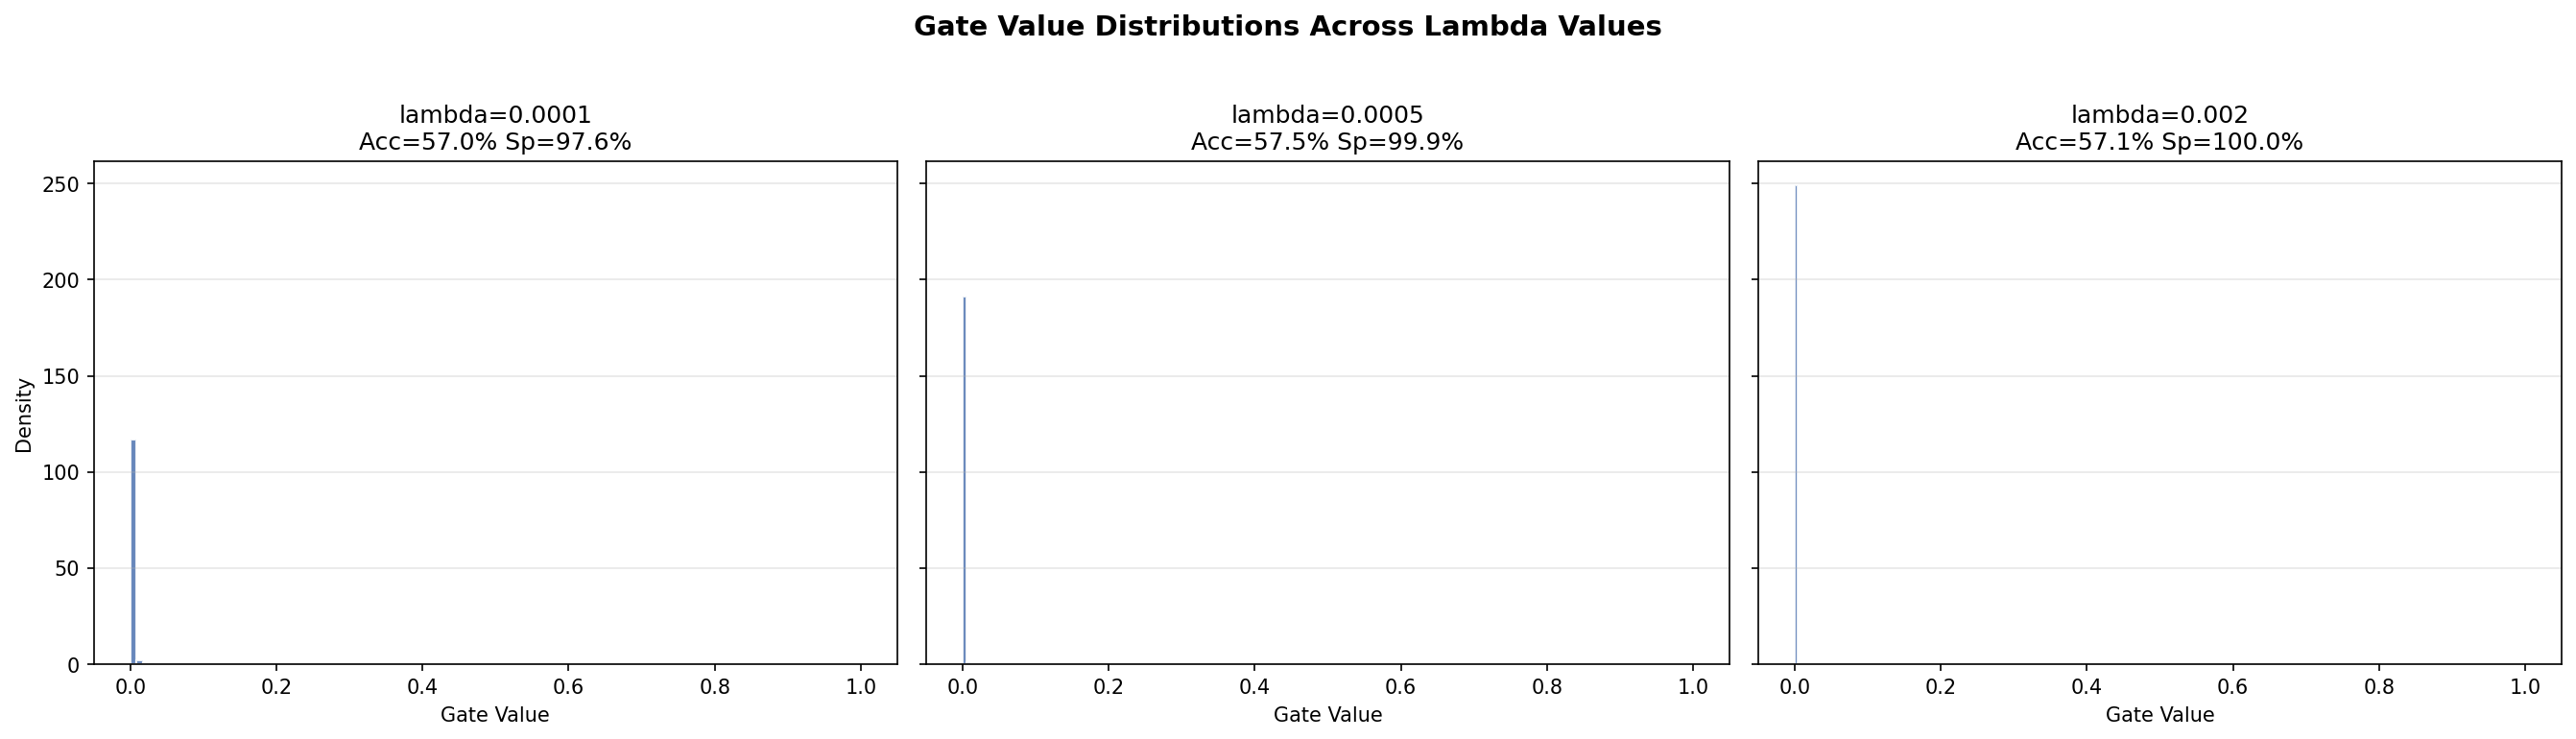


=== Training Curves ===


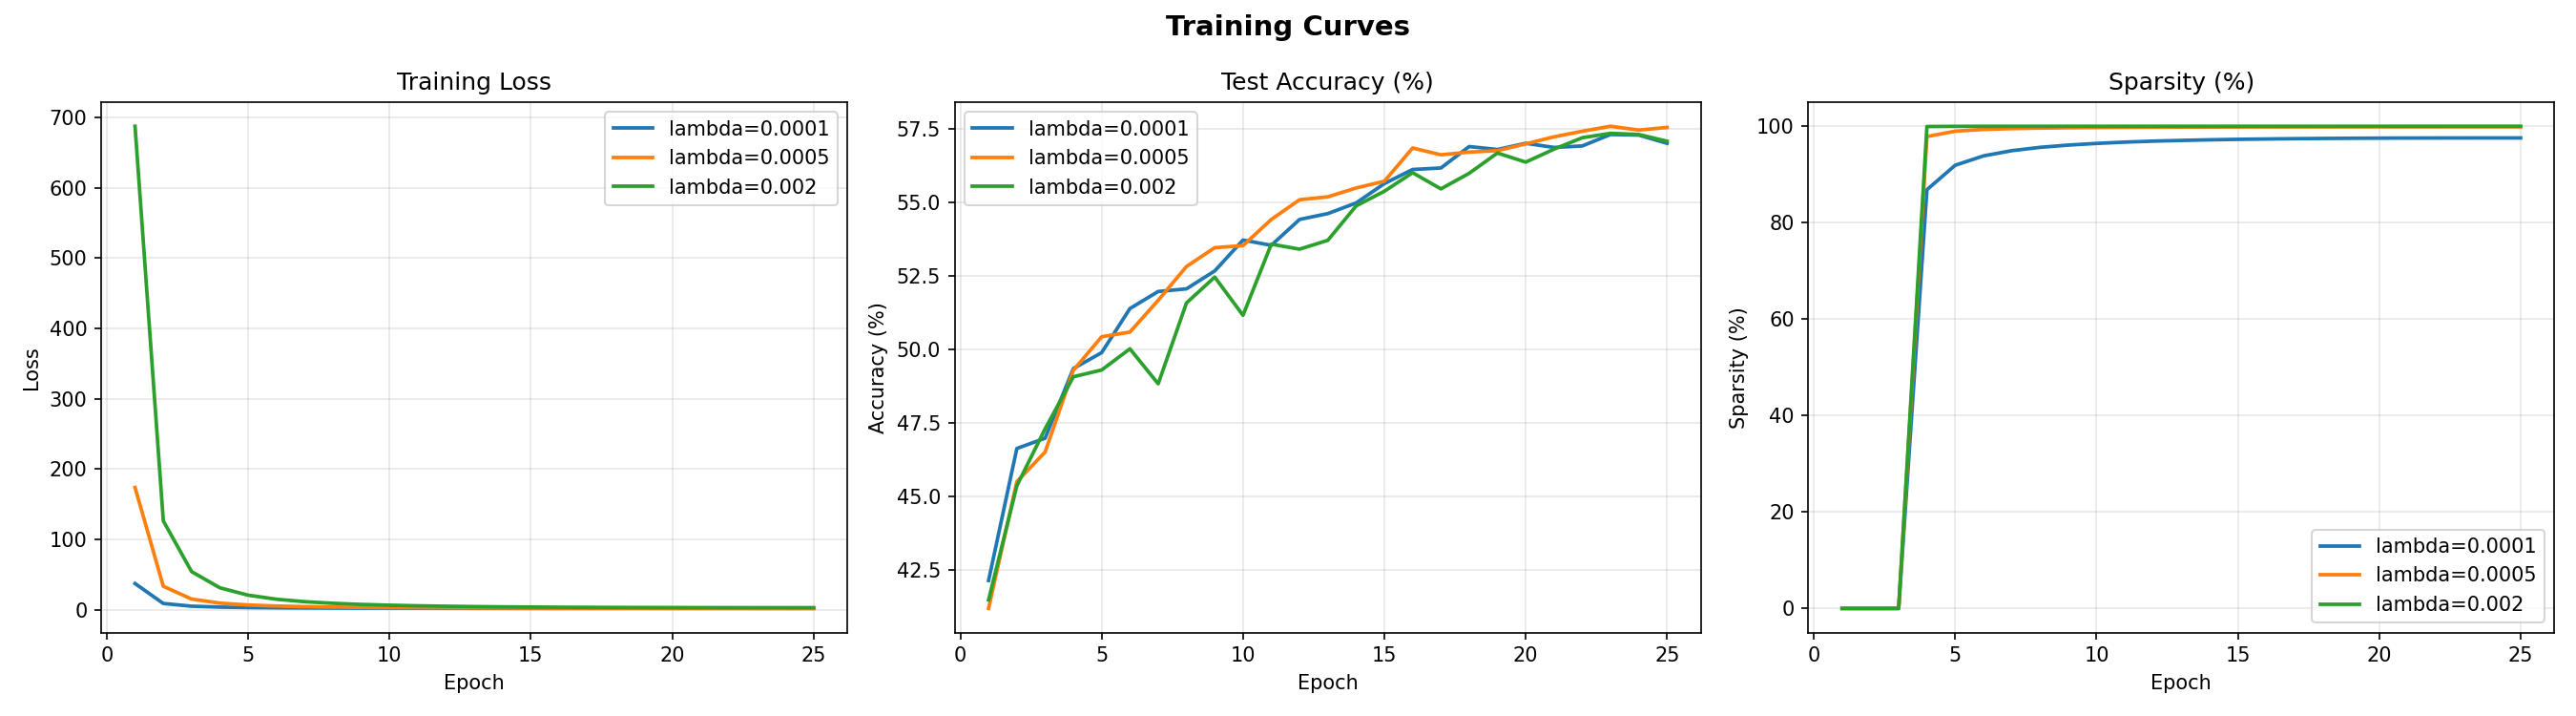


=== REPORT.md ===


# Self-Pruning Neural Network - Results Report

## Why L1 on Sigmoid Gates Encourages Sparsity

The L1 norm applies a constant gradient regardless of parameter magnitude. Even tiny gate values still feel downward pressure, driving them to zero. Each weight is multiplied by sigmoid(gate_score). Adding lambda * sum(gates) to the loss penalises active gates. Unimportant gates are pushed to large negative scores (sigmoid -> 0). The trade-off is controlled by lambda.

## Results Summary

| Lambda | Test Accuracy (%) | Sparsity (%) |
|:------:|:-----------------:|:------------:|
| 0.0001 | 57.00 | 97.6 |
| 0.0005 | 57.54 | 99.9 |
| 0.002 | 57.07 | 100.0 |

## Plots

![Comparison](gate_dist_comparison.png)

![Training Curves](training_curves.png)

## Analysis

- Best accuracy: lambda=0.0005 -> 57.54% with 99.9% sparsity.
- Highest sparsity: lambda=0.002 -> 100.0% with 57.07% accuracy.
- Increasing lambda drives more gates to zero but may degrade accuracy.
- Gate histograms show the desired bimodal distribution: spike near 0 (pruned) + cluster near 1 (retained).

In [10]:
from IPython.display import Image, display, Markdown

print("=== Gate Value Distributions ===")
display(Image(filename=os.path.join(OUTPUT_DIR, "gate_dist_comparison.png")))

print("\n=== Training Curves ===")
display(Image(filename=os.path.join(OUTPUT_DIR, "training_curves.png")))

print("\n=== REPORT.md ===")
with open(os.path.join(OUTPUT_DIR, "REPORT.md")) as f:
    display(Markdown(f.read()))


## Cell 11 — Download Results

Zips `/content/results/` and downloads it to your local machine.


In [11]:
import shutil
from google.colab import files

zip_path = "/content/self_pruning_results"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"Archive: {zip_path}.zip")
files.download(f"{zip_path}.zip")
print("Download triggered ✓")


Archive: /content/self_pruning_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered ✓
